# Demo

## Create the simulation

In [ ]:
import numpy as np
from lucifex.fem import grid_cross_section
from lucifex.io import write
from lucifex.sim import run, xdmf_to_npz, Simulation
from lucifex.viz import (
    plot_colormap, plot_contours, plot_line, get_ipynb_file_name, set_ipynb_variable,
)
from lucifex.utils.array_utils import as_index
from crocodil.dns.theory import threshold_rayleigh
from crocodil.dns.system_b import dns_system_b, thermal_rayleigh, SYSTEM_B_REFERENCE

STORE = 1
WRITE = None
DIR_ROOT = f'./{get_ipynb_file_name()}'
NX = set_ipynb_variable('NX', 80)
NY = set_ipynb_variable('NY', 80)
ANIM = set_ipynb_variable('ANIM', False)

theta_neg_opts = (True, False)
simulations: dict[bool, Simulation] = {}

for theta_neg in theta_neg_opts:
    simulations[theta_neg] = dns_system_b(
        store_delta=STORE, 
        write_delta=WRITE, 
        dir_root=DIR_ROOT, 
        dir_datetime=True,
        dir_uid=True,
    )(
        Nx=NX,
        Ny=NY,
        cell='quadrilateral',
        scaling='advective',
        **SYSTEM_B_REFERENCE,
        theta_neg=theta_neg,
        dt_max=0.1,
        courant_adv=0.75,
        courant_diff=0.75,
        courant_reac=0.1,
        c_stabilization=None,
        theta_stabilization=None,
        c_limits=True,
        theta_limits=True,
        diagnostic=True,
    )
    if theta_neg:
        Ra, Le, gamma, Lx, Ly = (
            float(i) for i in simulations[theta_neg]['Ra', 'Le', 'gamma', 'Lx', 'Ly']
        )
        Ra_thermal = thermal_rayleigh(Ra, Le, gamma)
        Ra_thresh = threshold_rayleigh(Lx, Ly, NX, 2)
        print(f"Ra_solutal = {Ra} , Ra_thermal = {Ra_thermal} , Ra_thresh = {Ra_thresh}")

Ra_solutal = 1000.0 , Ra_thermal = 1000.0 , Ra_thresh = 1800.0


## Run the simulation

In [2]:
n_stop = set_ipynb_variable('N_STOP', 150)
t_stop = 100.0
dt_init = 1e-6
n_init = 10

for theta_neg in theta_neg_opts:
    sim = simulations[theta_neg]
    write(sim.parameters, sim.parameter_file, sim.dir_path, mode='w')
    run(sim, n_stop=n_stop, t_stop=t_stop, dt_init=dt_init, n_init=n_init, show_progress=True)
    if WRITE: xdmf_to_npz(sim, delete_xdmf=False)

100%|██████████| 150/150 [02:04<00:00,  1.21it/s]


## Physical diagnostics

### Solutal and thermal flux

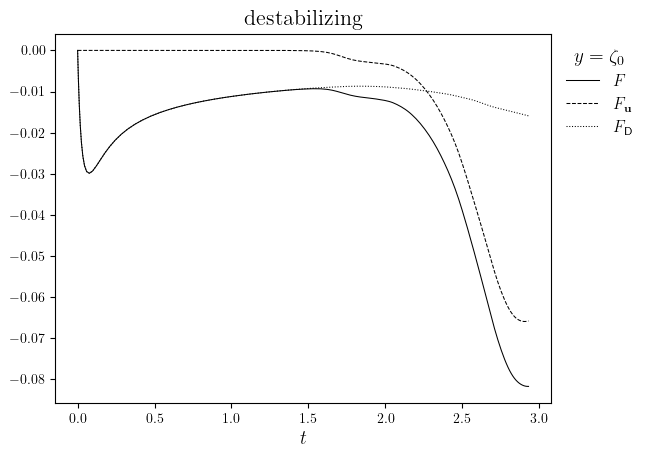

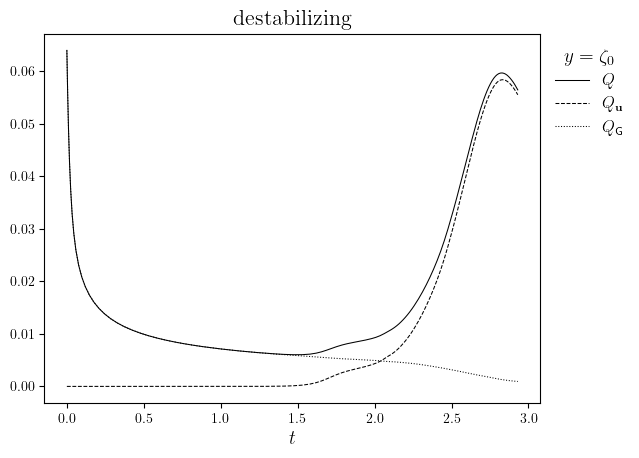

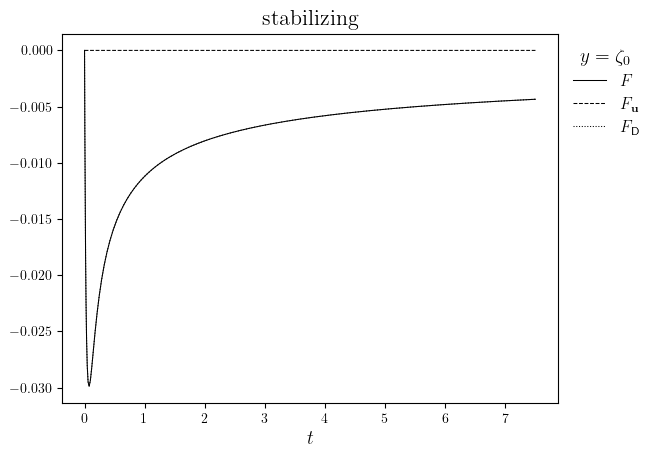

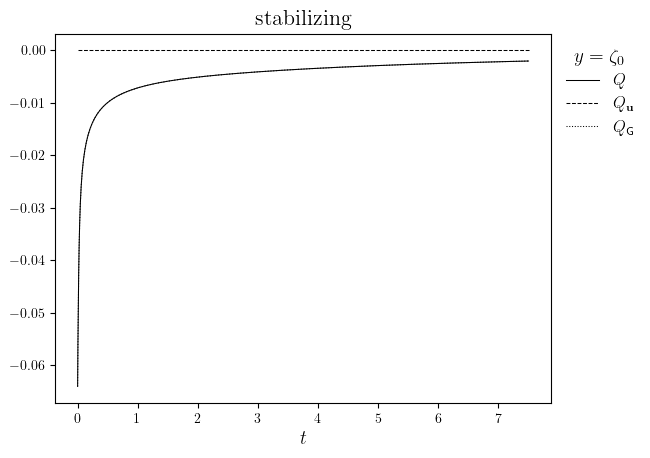

In [9]:
for theta_neg in theta_neg_opts:
    sim = simulations[theta_neg]
    f, q = sim['f', 'q']
    fZeta0, fZetaPlus, fZetaMinus = f.split()
    qZeta0, qZetaPlus, qZetaMinus = q.split()
    title = 'destabilizing' if theta_neg else 'stabilizing'
    fig, ax = plot_line(
        [(fZeta0.time_series, [np.sum(i) for i in fZeta0.value_series]), (fZeta0.time_series, fZeta0.value_series)],
        cyc='black',
        x_label='$t$',
        title=title,
        legend_labels=['$F$', '$F_{\mathbf{u}}$', '$F_{\mathsf{D}}$'],
        legend_title=f'$y=\zeta_0$',
    )
    fig, ax = plot_line(
        [(qZeta0.time_series, [np.sum(i) for i in qZeta0.value_series]), (qZeta0.time_series, qZeta0.value_series)],
        cyc='black',
        x_label='$t$',
        title=title,
        legend_labels=['$Q$', '$Q_{\mathbf{u}}$', '$Q_{\mathsf{G}}$'],
        legend_title=f'$y=\zeta_0$',
    )

### Colormaps

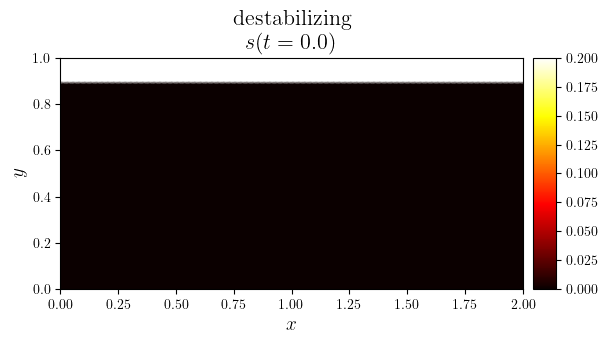

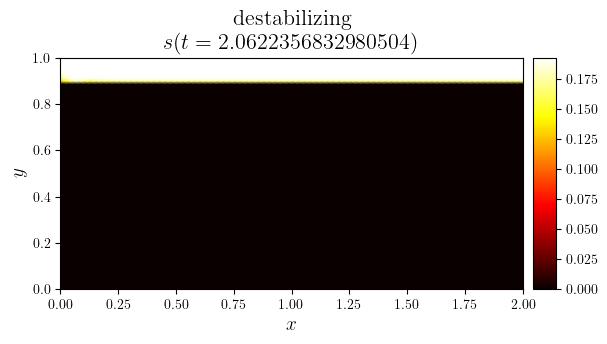

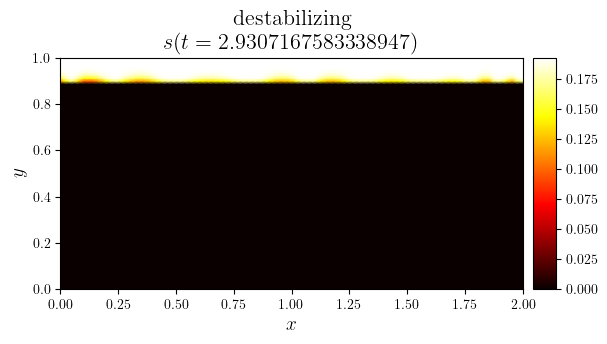

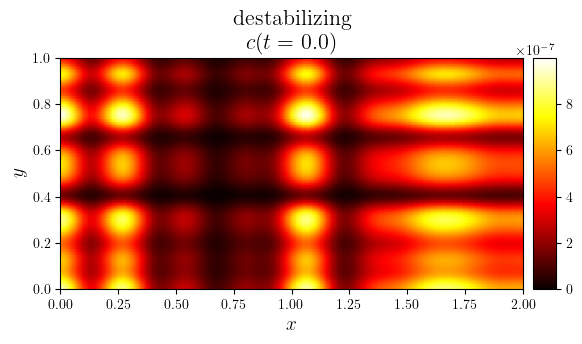

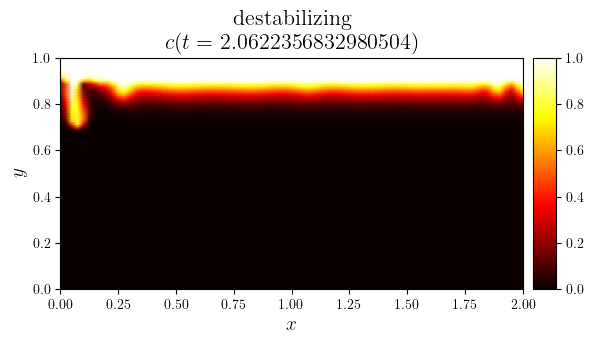

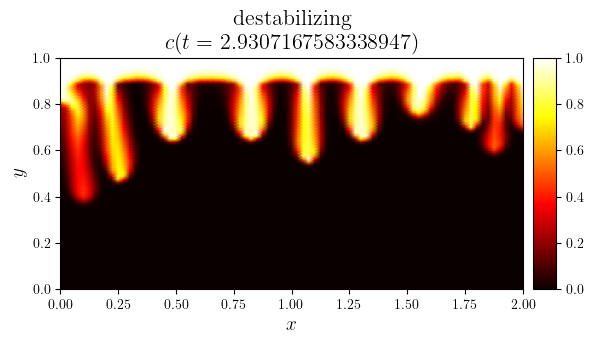

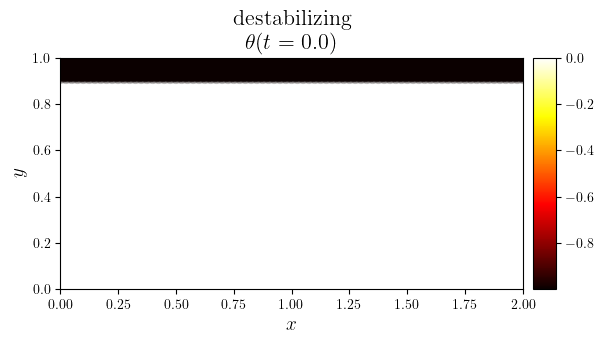

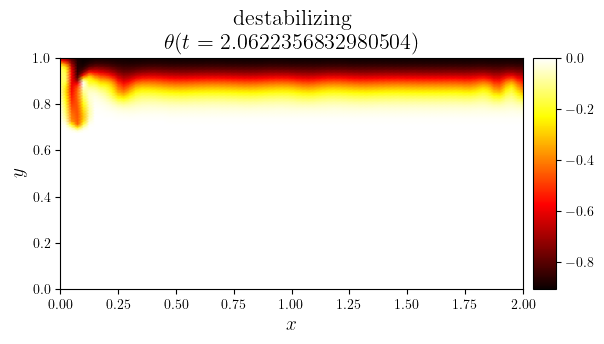

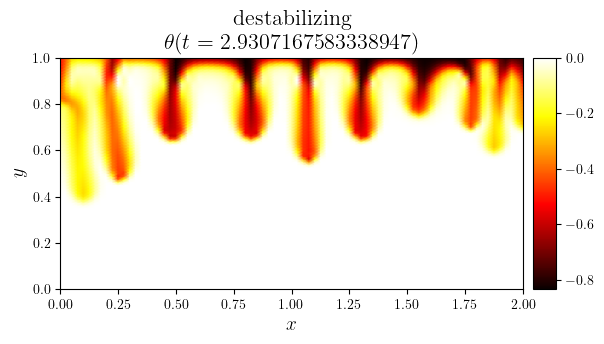

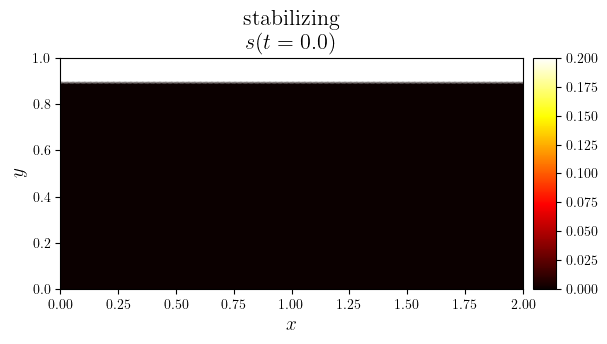

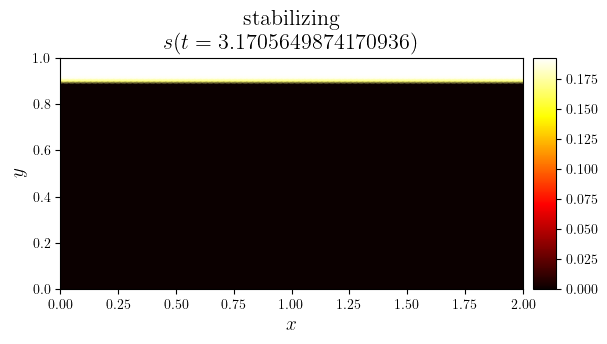

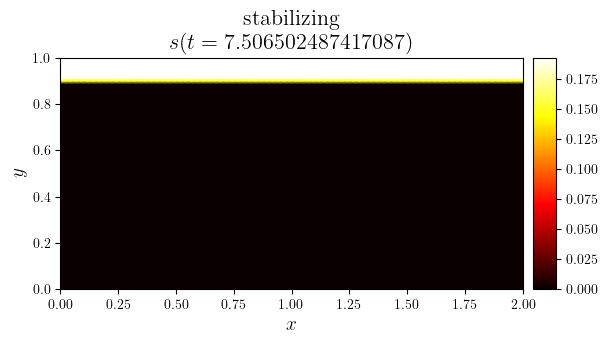

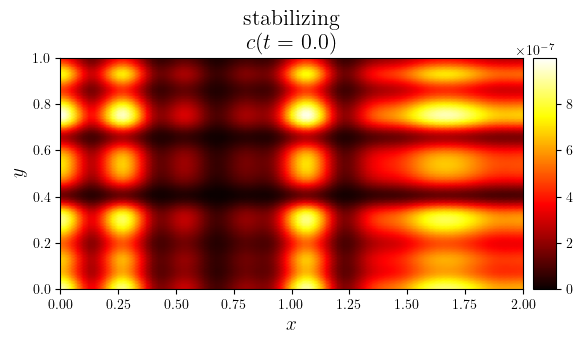

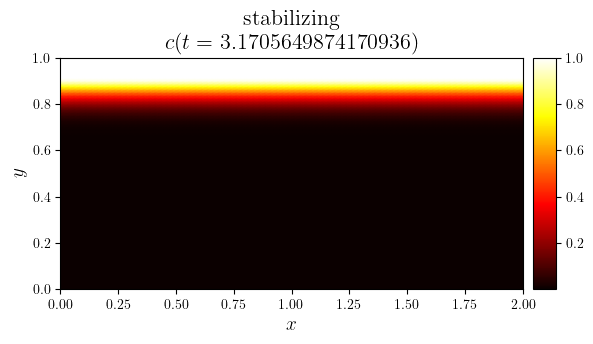

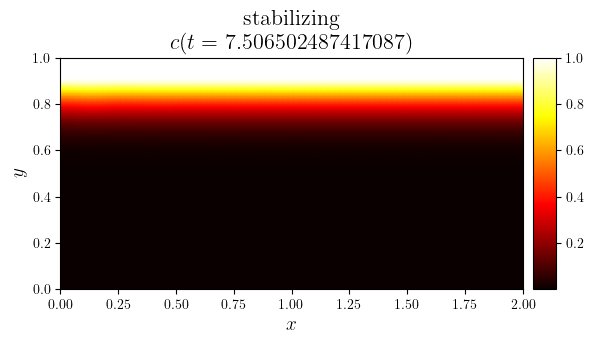

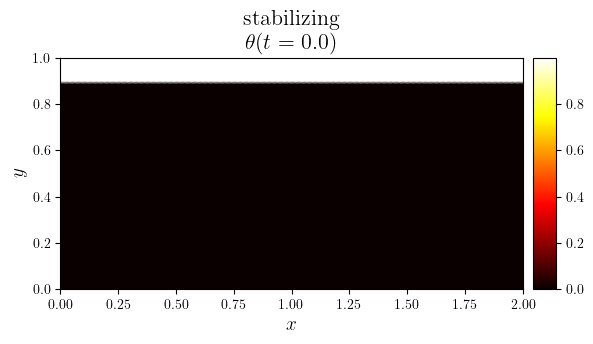

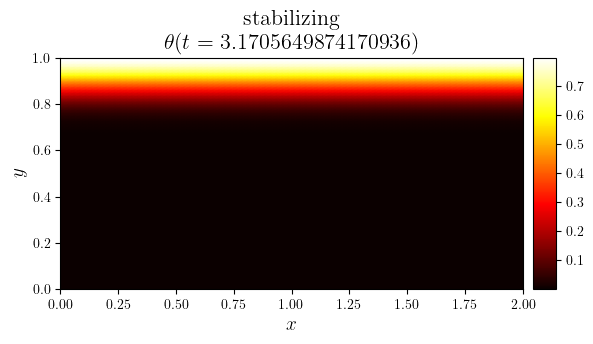

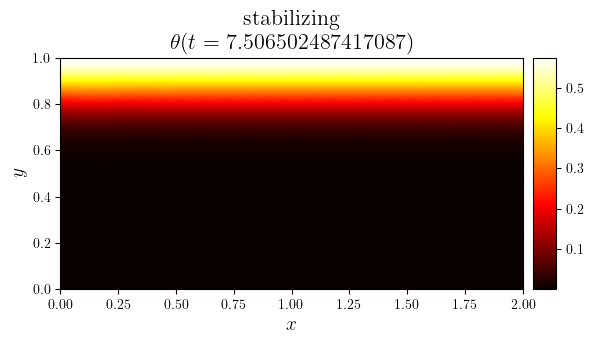

In [ ]:
tex_triplet = ('s', 'c', '\\theta')
index_targets = (0, 0.5, -1)

for theta_neg in theta_neg_opts:
    sim = simulations[theta_neg]
    s, c, theta = sim['s', 'c', 'theta']
    time_indices = as_index(c.time_series, index_targets, fraction=True)
    suptitle = 'destabilizing' if theta_neg else 'stabilizing'
    for q, tex in zip((s, c, theta), tex_triplet):
        for i in time_indices:
            fig, ax = plot_colormap(q.series[i], title=f'{suptitle}\n${tex}(t={q.time_series[i]})$')

## Numerical diagnostics

### Velocity norms

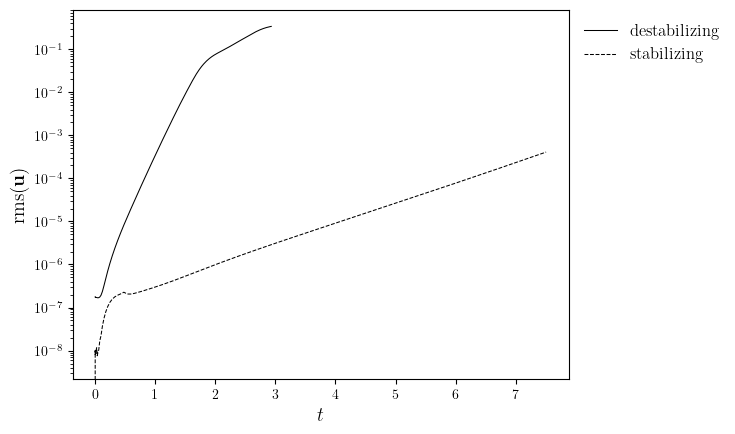

In [8]:
lines = []

for theta_neg in theta_neg_opts:
    sim = simulations[theta_neg]
    uRMS = sim['uRMS']
    lines.append((uRMS.time_series, uRMS.value_series))

fig, ax = plot_line(
    lines, 
    x_label='$t$', 
    y_label='$\mathrm{rms}(\mathbf{u})$', 
    legend_labels=['destabilizing', 'stabilizing'],
)
ax.set_yscale('log')

### Saturation, concentration and temperature limits

In [ ]:
for theta_neg in theta_neg_opts:
    sim = simulations[theta_neg]
    sMinMax, cMinMax, thetaMinMax = sim['sMinMax', 'cMinMax', 'thetaMinMax']
    for minmax in (sMinMax, cMinMax, thetaMinMax):
        fig, ax = plot_line((minmax.time_series, minmax.value_series), cyc='black')